# Hospital Readmission Prediction Project

## Dataset
The dataset used in this project was obtained from Kaggle — a synthetic
hospital readmission dataset created for educational and machine learning
practice purposes.

- **Source:** Kaggle
- **Dataset Name:** Hospital Readmission Prediction (Synthetic Dataset)
- **Records:** 30,000 patients
- **Link:** https://www.kaggle.com/datasets/siddharth0935/hospital-readmission-predictionsynthetic-dataset

Analyzing the Predictors of Patient Readmission After 30 Days: Whether It Is Driven by Diabetes-Related Clinical Factors, Nursing discharge destination, or Other Variables in the Dataset.

### Objectives:

1. To predict the major cause of patient readmisssion after 30 days
2. To provide actionable insights that enable doctors and nurses to better prepare for and manage patient readmissions, ensuring proper care is in place for returning patients
3. To recommend data-driven strategies that hospital administrators can implement to reduce preventable readmissions.

In [392]:
# import library and packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [393]:
# read the dataset
df = pd.read_csv("data/hospital_readmissions_30k.csv")

df



,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,112/80,157,31.4,No,No,4,10,Home,Yes
29996,29997,20,Other,146/83,198,30.2,No,Yes,4,1,Home,Yes
29997,29998,40,Other,131/96,275,23.3,Yes,Yes,7,2,Home,No
29998,29999,61,Other,124/75,232,34.3,No,No,5,3,Home,No


In [394]:
print(df.shape)

(30000, 12)


In [395]:
print(df.head)


<bound method NDFrame.head of        patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0               1   74   Other         130/72          240  31.5      Yes   
1               2   46  Female         120/92          292  36.3       No   
2               3   89   Other         135/78          153  30.3       No   
3               4   84  Female         123/80          153  31.5       No   
4               5   32   Other         135/84          205  18.4       No   
...           ...  ...     ...            ...          ...   ...      ...   
29995       29996   29    Male         112/80          157  31.4       No   
29996       29997   20   Other         146/83          198  30.2       No   
29997       29998   40   Other         131/96          275  23.3      Yes   
29998       29999   61   Other         124/75          232  34.3       No   
29999       30000   78  Female         148/77          240  35.5      Yes   

      hypertension  medication_count  length_

In [396]:
print(df["readmitted_30_days"].value_counts())  # Check readmitted and non readmitted

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [397]:
print(df.isnull().values.any()) # checking for null data in my dataset

False


In [398]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB
None


In [399]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


In [400]:
df

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,112/80,157,31.4,No,No,4,10,Home,Yes
29996,29997,20,Other,146/83,198,30.2,No,Yes,4,1,Home,Yes
29997,29998,40,Other,131/96,275,23.3,Yes,Yes,7,2,Home,No
29998,29999,61,Other,124/75,232,34.3,No,No,5,3,Home,No


In [401]:
#  Define numerical columns
num_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

# Convert to numerical data
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='raise')

# Verify
print(df[num_cols].dtypes)



age                   int64
cholesterol           int64
bmi                 float64
medication_count      int64
length_of_stay        int64
dtype: object


In [402]:

# Splitn the blood_pressure column
df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True)
df['systolic'] = df['systolic'].astype(float)
df['diastolic'] = df['diastolic'].astype(float)

# Drop blood_pressure column since it's no longer needed
df.drop(columns=['blood_pressure'], inplace=True)

# Verify
print(df[['systolic', 'diastolic']].head(1))
print(df[['systolic', 'diastolic']].dtypes)

   systolic  diastolic
0     130.0       72.0
systolic     float64
diastolic    float64
dtype: object


In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   cholesterol            30000 non-null  int64  
 4   bmi                    30000 non-null  float64
 5   diabetes               30000 non-null  object 
 6   hypertension           30000 non-null  object 
 7   medication_count       30000 non-null  int64  
 8   length_of_stay         30000 non-null  int64  
 9   discharge_destination  30000 non-null  object 
 10  readmitted_30_days     30000 non-null  object 
 11  systolic               30000 non-null  float64
 12  diastolic              30000 non-null  float64
dtypes: float64(3), int64(5), object(5)
memory usage: 3.0+ MB


In [404]:
# find the duplicate
df.duplicated().sum()

np.int64(0)

In [405]:
df

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic,diastolic
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130.0,72.0
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120.0,92.0
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135.0,78.0
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123.0,80.0
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,157,31.4,No,No,4,10,Home,Yes,112.0,80.0
29996,29997,20,Other,198,30.2,No,Yes,4,1,Home,Yes,146.0,83.0
29997,29998,40,Other,275,23.3,Yes,Yes,7,2,Home,No,131.0,96.0
29998,29999,61,Other,232,34.3,No,No,5,3,Home,No,124.0,75.0


In [406]:
cat_columns = ["gender","diabetes", "hypertension", "discharge_destination", "readmitted_30_days"]

for col in cat_columns:
    df[col] = df[col].astype("category")
# Verify everything looks right
print(df.dtypes)

patient_id                  int64
age                         int64
gender                   category
cholesterol                 int64
bmi                       float64
diabetes                 category
hypertension             category
medication_count            int64
length_of_stay              int64
discharge_destination    category
readmitted_30_days       category
systolic                  float64
diastolic                 float64
dtype: object


In [407]:
# Drop irrelevant column
df.drop(columns=['patient_id'], axis=1, inplace=True)

In [408]:
df

,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic,diastolic
0,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130.0,72.0
1,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120.0,92.0
2,89,Other,153,30.3,No,Yes,1,1,Home,No,135.0,78.0
3,84,Female,153,31.5,No,Yes,3,10,Home,No,123.0,80.0
4,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,Male,157,31.4,No,No,4,10,Home,Yes,112.0,80.0
29996,20,Other,198,30.2,No,Yes,4,1,Home,Yes,146.0,83.0
29997,40,Other,275,23.3,Yes,Yes,7,2,Home,No,131.0,96.0
29998,61,Other,232,34.3,No,No,5,3,Home,No,124.0,75.0


## Visualization

In [409]:

# chcking the class imbalance
df["readmitted_30_days"].value_counts().plot(kind="bar")

<Axes: xlabel='readmitted_30_days'>

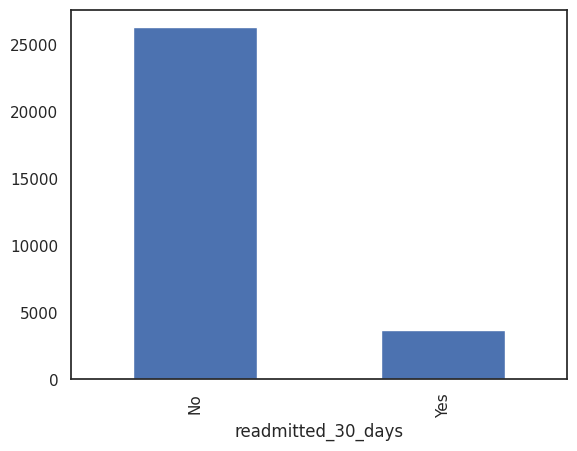

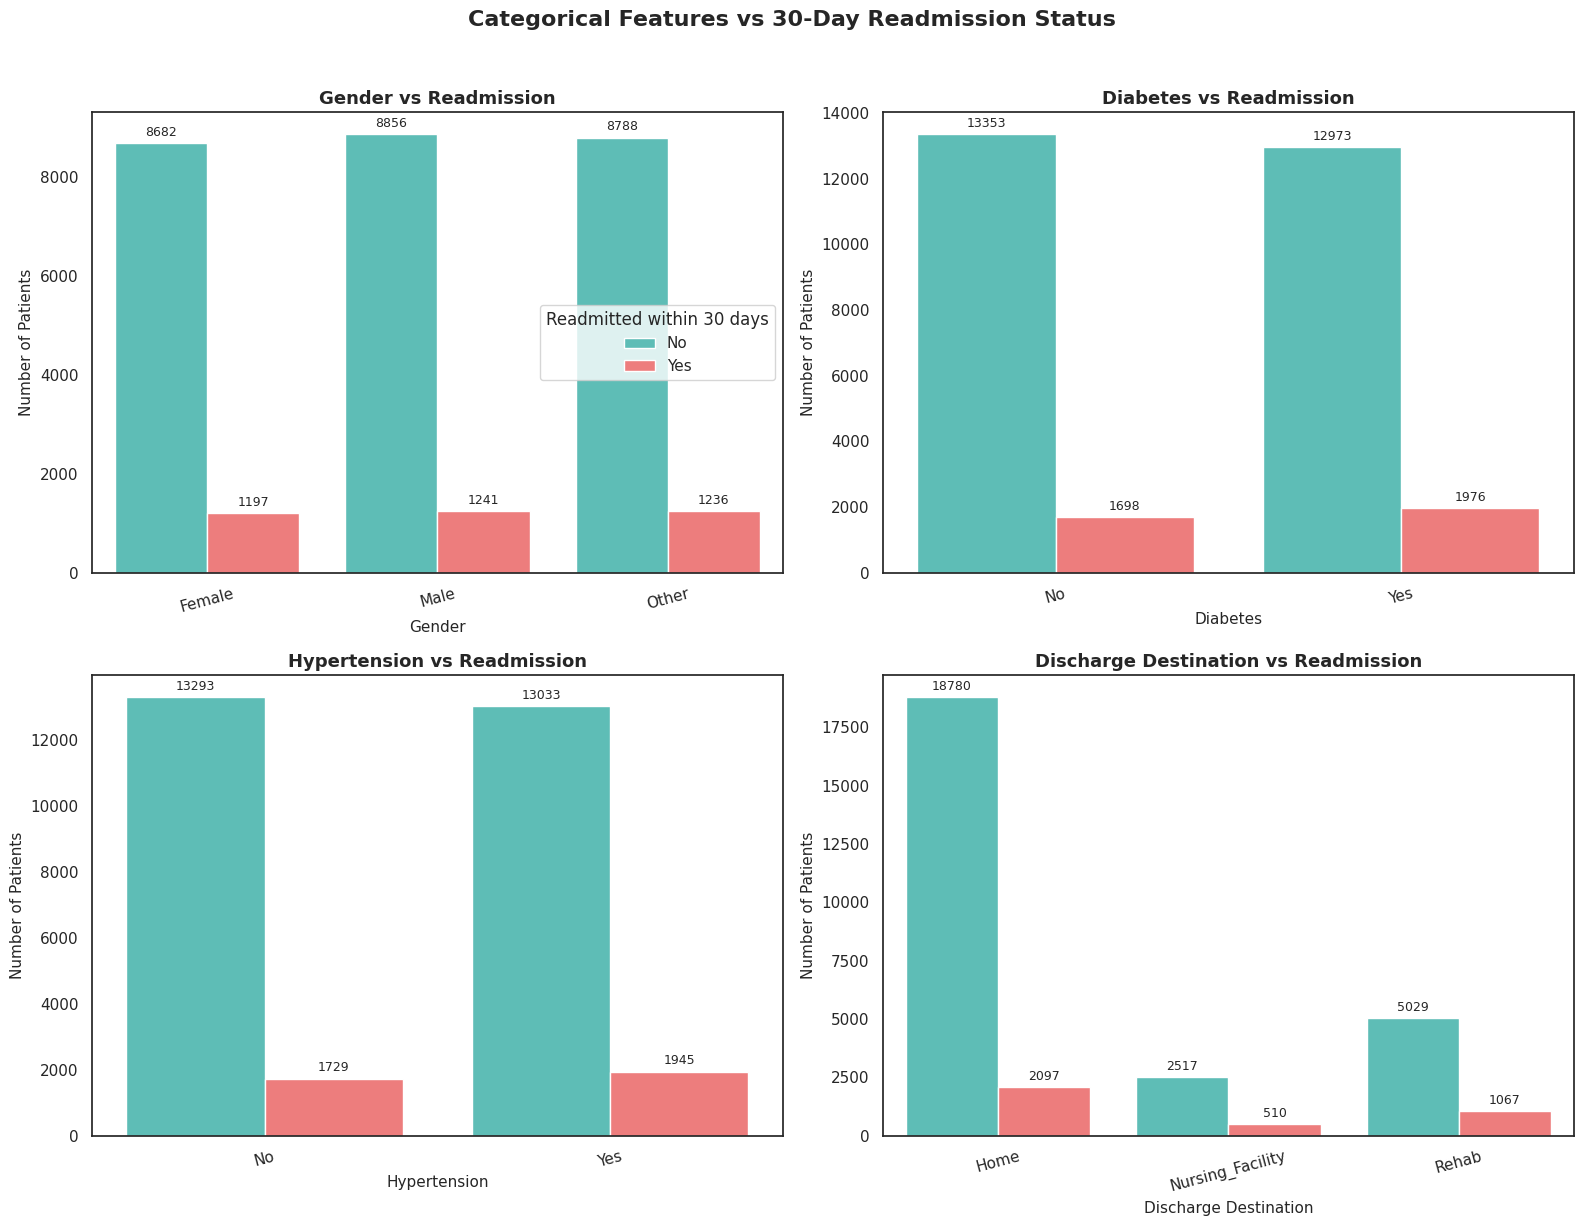

In [410]:

#  define the categorical column
cat_columns = ['gender', 'diabetes', 'hypertension', 'discharge_destination']

palette = {'Yes': '#FF6B6B', 'No': '#4ECDC4'}


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_columns):
    ax=axes[i]
    sns.countplot(
        data=df,
        x=col,
       hue='readmitted_30_days',
        hue_order=['No', 'Yes'],
        palette=palette,
        ax=ax

    )
     # Add count label on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=3)

    ax.set_title(f'{col.replace("_", " ").title()} vs Readmission',
                      fontsize=13, fontweight='bold')
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel('Number of Patients', fontsize=11)
    ax.tick_params(axis='x', rotation=15)  # Rotates long labels like discharge_destination
    if i == 0:
        ax.legend(title='Readmitted within 30 days')
    else:
        ax.get_legend().remove()

plt.suptitle('Categorical Features vs 30-Day Readmission Status',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


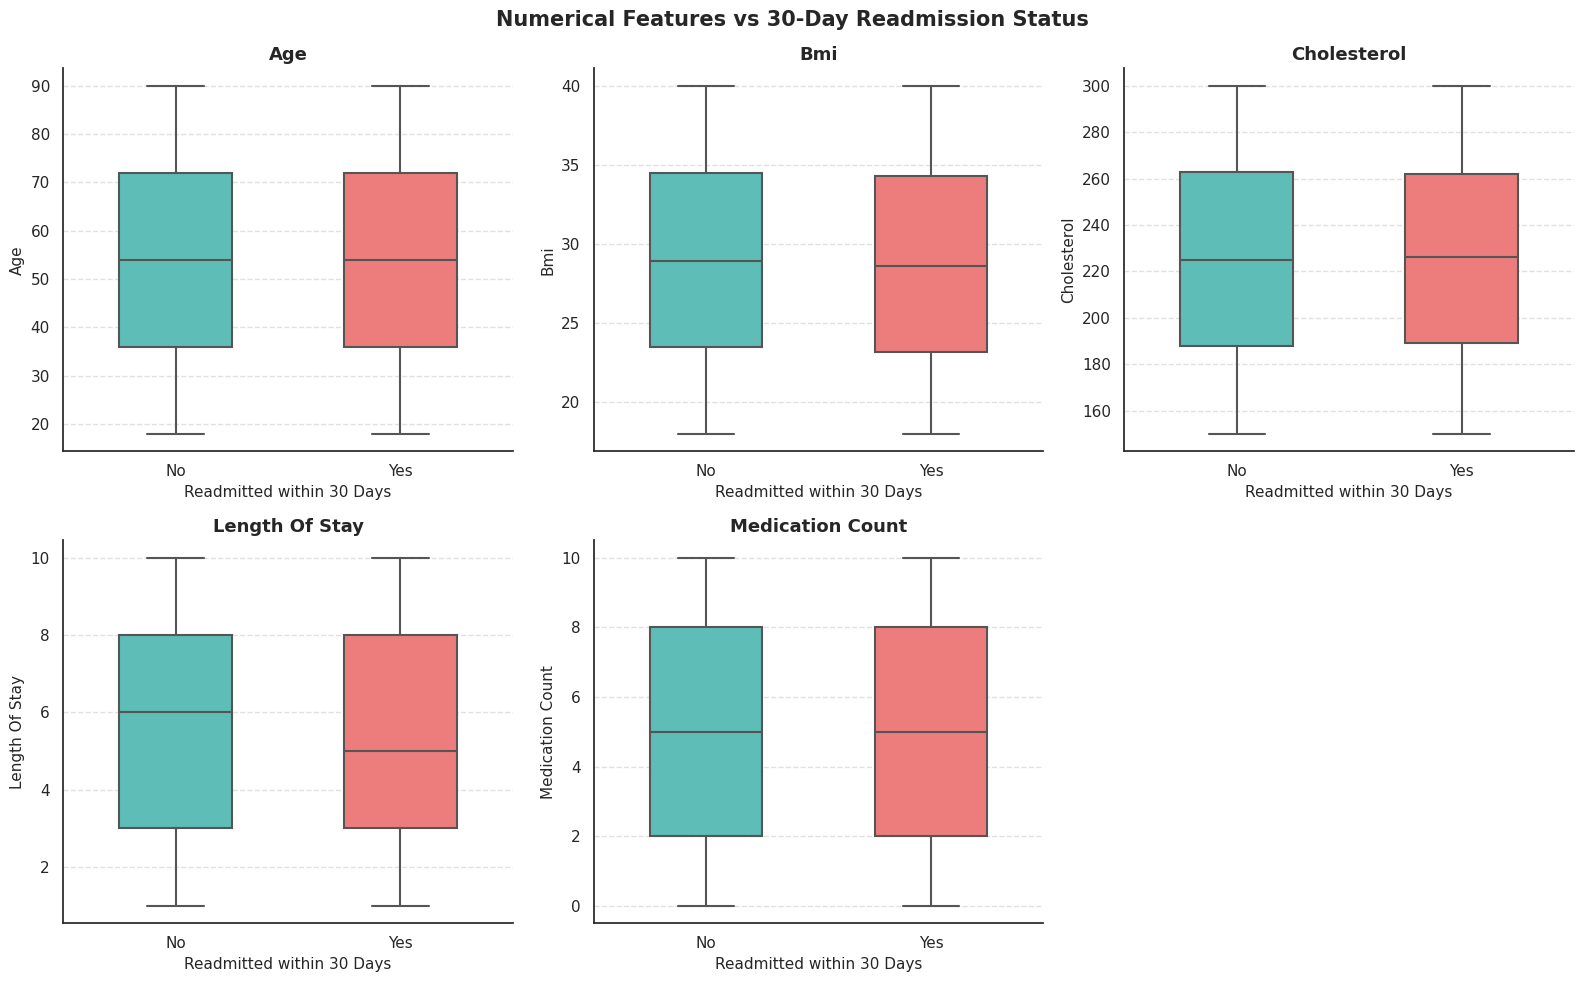

In [411]:
num_columns = ['age', 'bmi', 'cholesterol', 'length_of_stay', 'medication_count']
palette = {'No': '#4ECDC4', 'Yes': '#FF6B6B'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    ax = axes[i]
    sns.boxplot(
        data=df,
        x='readmitted_30_days',
        y=col,
        hue='readmitted_30_days',
        order=['No', 'Yes'],
        palette=palette,
        width=0.5,
        linewidth=1.5,
        ax=ax
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Readmitted within 30 Days', fontsize=11)
    ax.set_ylabel(col.replace("_", " ").title(), fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
axes[-1].set_visible(False)  # Hide empty 6th subplot

plt.suptitle(
    'Numerical Features vs 30-Day Readmission Status',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

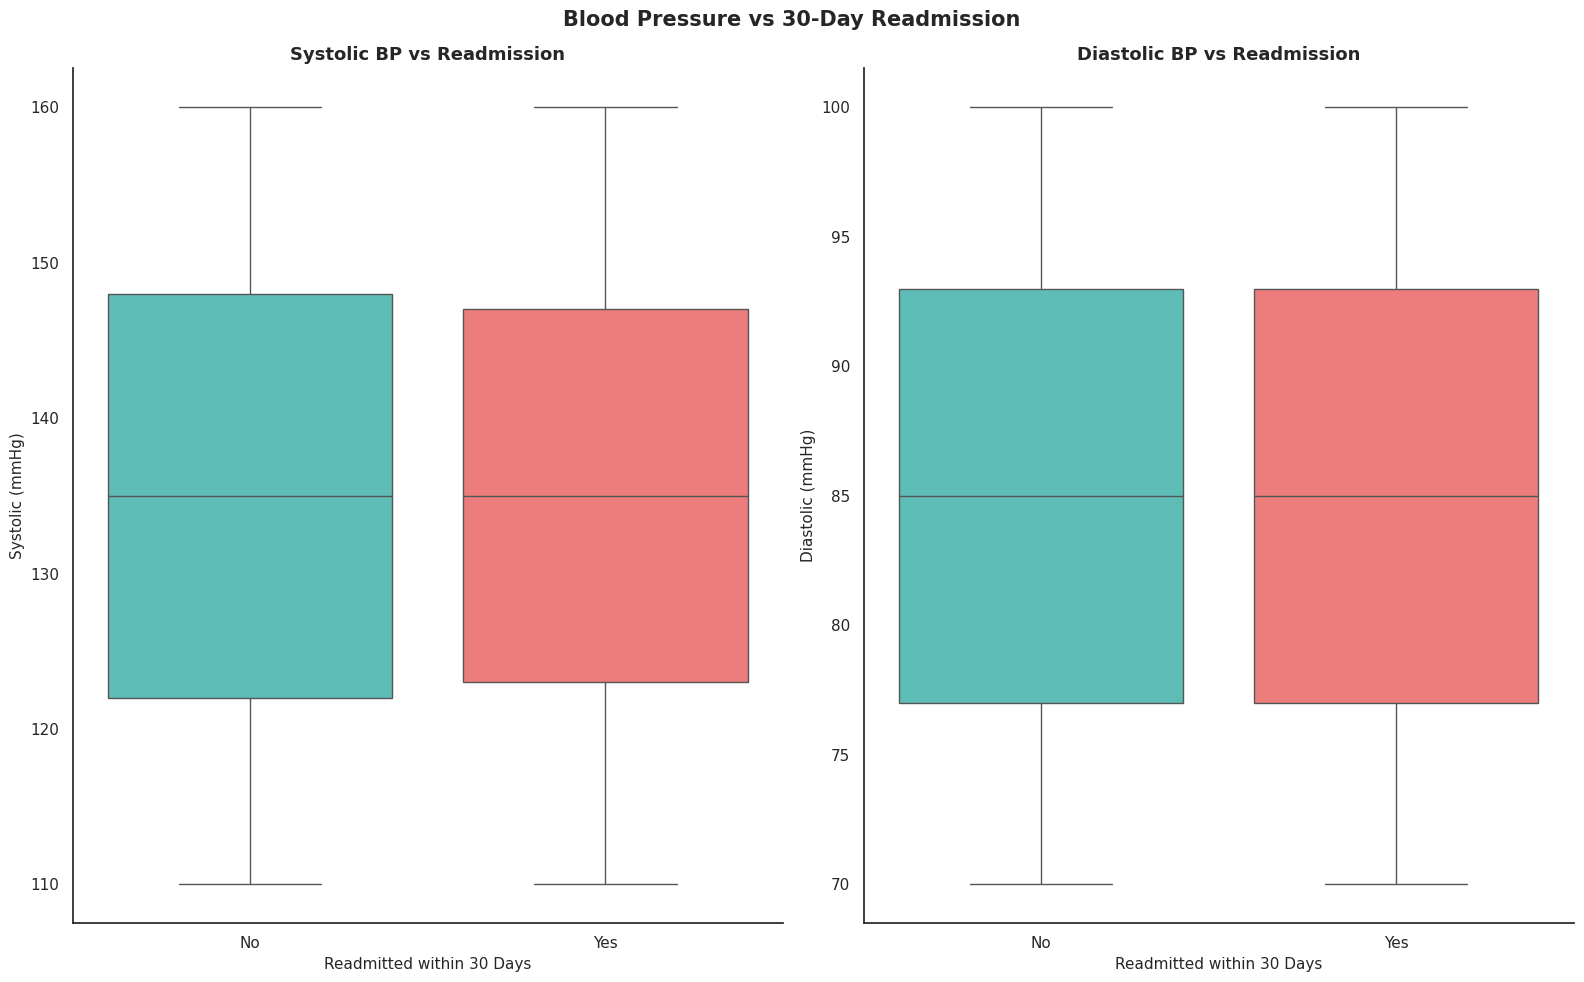

In [412]:
# Comparing  the systolic and the diastolic with the readmitted_30_days


fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(['systolic', 'diastolic']):
    ax=axes[i]
    sns.boxplot(
        data=df,
        x='readmitted_30_days',
        y=col,
        hue='readmitted_30_days',
        order=['No', 'Yes'],
        palette={'No': '#4ECDC4', 'Yes': '#FF6B6B'},
        ax=ax

    )
    ax.set_title(f'{col.title()} BP vs Readmission', fontsize=13, fontweight='bold')
    ax.set_xlabel('Readmitted within 30 Days', fontsize=11)
    ax.set_ylabel(f'{col.title()} (mmHg)', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    legend = ax.get_legend()
    if legend:
        legend.remove()

plt.suptitle('Blood Pressure vs 30-Day Readmission', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [413]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    30000 non-null  int64   
 1   gender                 30000 non-null  category
 2   cholesterol            30000 non-null  int64   
 3   bmi                    30000 non-null  float64 
 4   diabetes               30000 non-null  category
 5   hypertension           30000 non-null  category
 6   medication_count       30000 non-null  int64   
 7   length_of_stay         30000 non-null  int64   
 8   discharge_destination  30000 non-null  category
 9   readmitted_30_days     30000 non-null  category
 10  systolic               30000 non-null  float64 
 11  diastolic              30000 non-null  float64 
dtypes: category(5), float64(3), int64(4)
memory usage: 1.7 MB
None


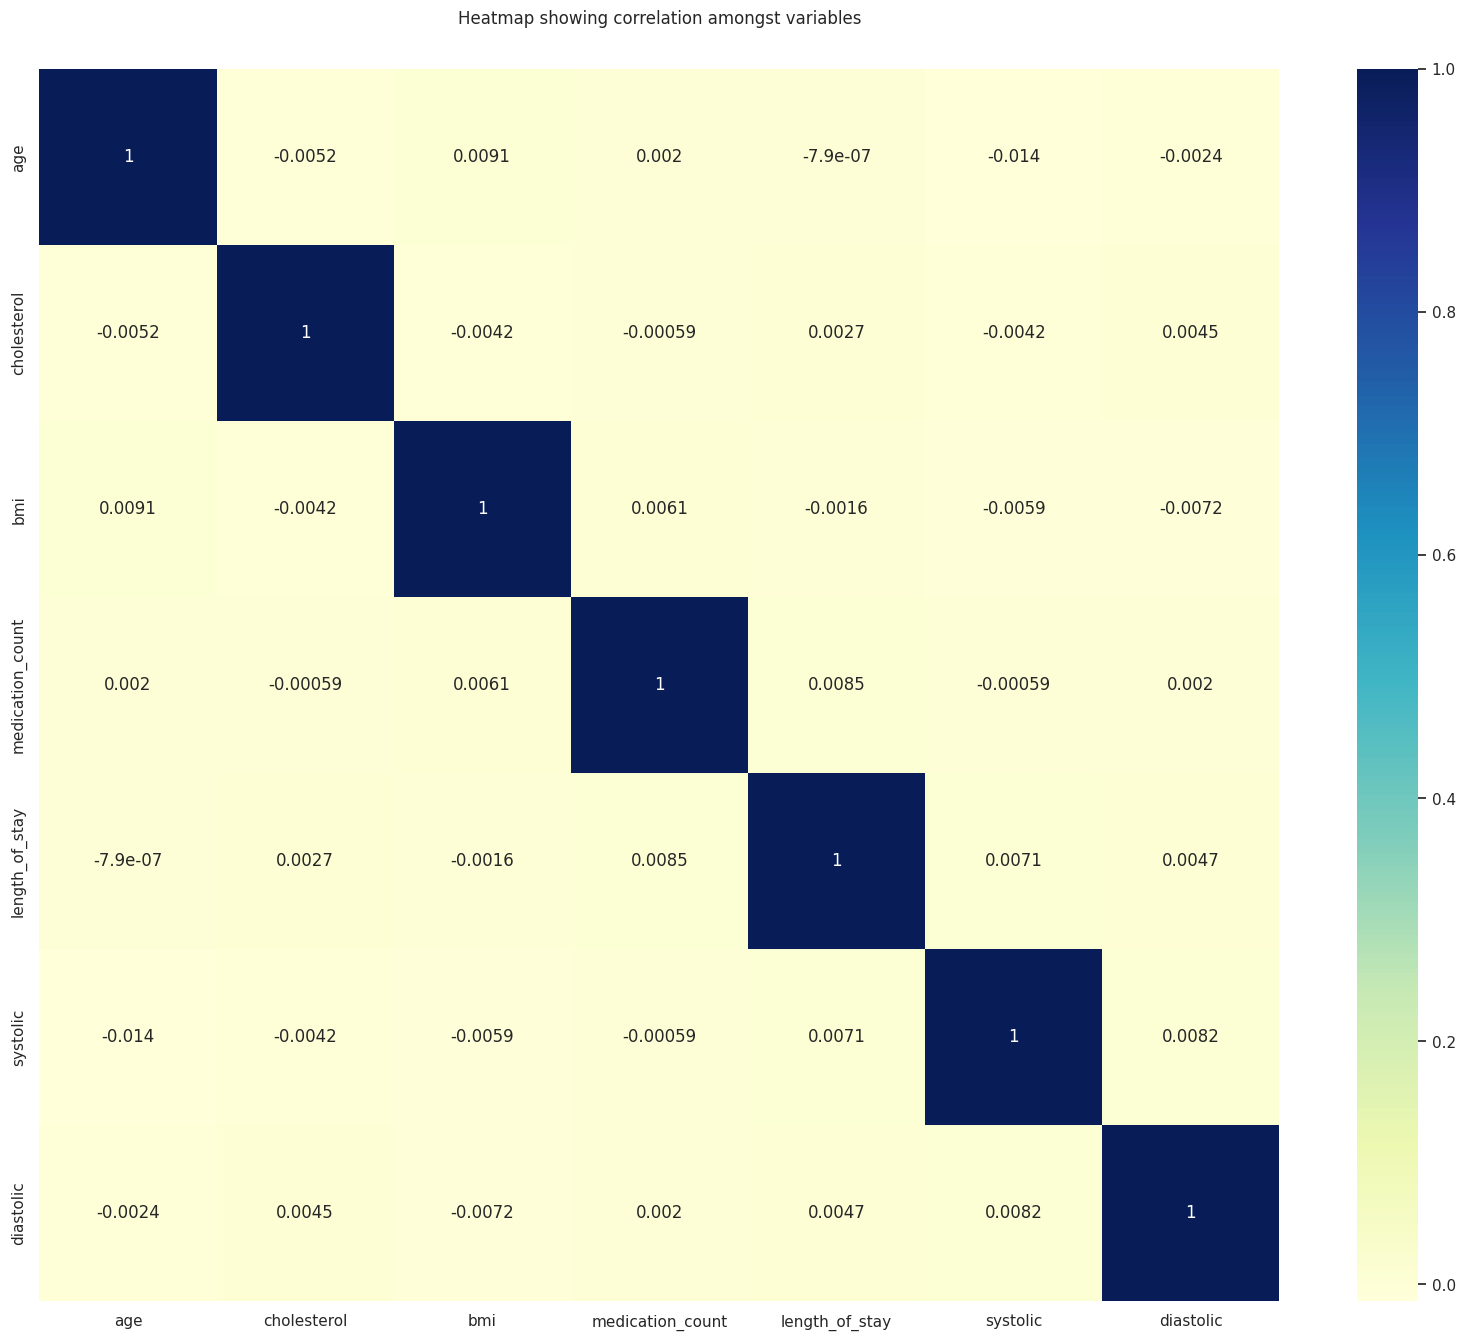

In [414]:

# PLotting an heatmap
plt.figure(figsize=(20,16))

sns.heatmap(df.corr(numeric_only=True), cmap='YlGnBu', fmt='.2g', annot=True)

plt.title('Heatmap showing correlation amongst variables', y=1.03)
plt.show()




Data visualization summary

From the heatmap, there is no significant correlation between any of the columns in the dataset. This indicates that each feature independently contributes unique information to the model, with no redundancy between variables.

In [415]:

print(df['readmitted_30_days'].unique())

['Yes', 'No']
Categories (2, object): ['No', 'Yes']


In [416]:
#checking the variance of variables
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count',
                'length_of_stay', 'systolic', 'diastolic']

print(df[numeric_cols].var())

age                  443.375544
cholesterol         1899.710716
bmi                   40.299693
medication_count      10.025984
length_of_stay         8.221399
systolic             215.251839
diastolic             79.621005
dtype: float64


Briefly Note that although we can notice there is a huge difference between the variance of the different columns i wont be standardizing or normalizing the variables as i would be using classification tree models because it has ability to describe non-linear dependencies and it does not require preprocessing of variables before modeling.

In [417]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    30000 non-null  int64   
 1   gender                 30000 non-null  category
 2   cholesterol            30000 non-null  int64   
 3   bmi                    30000 non-null  float64 
 4   diabetes               30000 non-null  category
 5   hypertension           30000 non-null  category
 6   medication_count       30000 non-null  int64   
 7   length_of_stay         30000 non-null  int64   
 8   discharge_destination  30000 non-null  category
 9   readmitted_30_days     30000 non-null  category
 10  systolic               30000 non-null  float64 
 11  diastolic              30000 non-null  float64 
dtypes: category(5), float64(3), int64(4)
memory usage: 1.7 MB


In [418]:
# Convert target column to 0 and 1
df['readmitted_30_days'] = (
    df['readmitted_30_days'].map({'Yes': 1, 'No': 0})
)


In [419]:
print(df['readmitted_30_days'].unique())

[1, 0]
Categories (2, int64): [0, 1]


In [420]:
# preprocessing categorical columns using pd.get_dummies
features = df.drop(['readmitted_30_days'], axis=1)

# encode categorical columns
X_features = pd.get_dummies(features, columns=['gender', 'hypertension',
                                                'diabetes', 'discharge_destination'])

# convert bool columns created by get_dummies to int
bool_columns = X_features.select_dtypes(include='bool').columns.tolist()
X_features[bool_columns] = X_features[bool_columns].astype(int)


X = X_features
y = df['readmitted_30_days']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Columns:', X.columns.tolist())
print('Dtypes:')
print(X.dtypes.value_counts())

X shape: (30000, 17)
y shape: (30000,)
Columns: ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic', 'diastolic', 'gender_Female', 'gender_Male', 'gender_Other', 'hypertension_No', 'hypertension_Yes', 'diabetes_No', 'diabetes_Yes', 'discharge_destination_Home', 'discharge_destination_Nursing_Facility', 'discharge_destination_Rehab']
Dtypes:
int64      14
float64     3
Name: count, dtype: int64


In [421]:
df

,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic,diastolic
0,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,1,130.0,72.0
1,46,Female,292,36.3,No,No,4,3,Nursing_Facility,0,120.0,92.0
2,89,Other,153,30.3,No,Yes,1,1,Home,0,135.0,78.0
3,84,Female,153,31.5,No,Yes,3,10,Home,0,123.0,80.0
4,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,0,135.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,Male,157,31.4,No,No,4,10,Home,1,112.0,80.0
29996,20,Other,198,30.2,No,Yes,4,1,Home,1,146.0,83.0
29997,40,Other,275,23.3,Yes,Yes,7,2,Home,0,131.0,96.0
29998,61,Other,232,34.3,No,No,5,3,Home,0,124.0,75.0


## Modeling

In [422]:
all_features = [col for col in df.columns if col != 'readmitted_30_days']

# Option 1: Use all available features
train_input = X_features
train_output = df['readmitted_30_days']

In [423]:
#importing library and packages
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

sns.set(style='white', context='notebook', palette='deep')

In [424]:
# Split the training and testing dataset
X_train, X_test, y_train, y_test= model_selection.train_test_split(train_input, train_output, random_state = 0, test_size=0.1)


In [425]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


In [426]:
X_features = X_train.columns.tolist()  # ✓ a simple list of 17 column name strings

In [427]:
import numpy as np
import pandas as pd

target_count = train_output.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)');

Class 0: 26326
Class 1: 3674
Proportion: 7.17 : 1


In [428]:
# Check for non-numeric columns in x_train
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols.tolist())

# Option 1: Remove non-numeric columns
X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

# Create and train the Logistic Regression model
LogR = LogisticRegression(random_state=0, max_iter=1000)
LogR.fit(X_train_numeric, y_train)

# Make predictions
y_pred = LogR.predict(X_test_numeric)

Non-numeric columns: []


In [429]:
# Run Logistic Regression
LogR = LogisticRegression(fit_intercept=True, penalty='l2',random_state = 0)
print("Cross Validation Score: {:.2%}".format(np.mean(cross_val_score(LogR, X_train, y_train, cv=10))))
LogR.fit(X_train, y_train)
print("Test Set score: {:.2%}".format(LogR.score(X_test, y_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Score: 87.82%
Test Set score: 87.17%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [430]:
pd.crosstab(pd.Series(y_test, name = 'Actual'), pd.Series(y_pred, name = 'Predict'), margins = True)

Predict,0,All
Actual,,
0,251,251
1,34,34
All,285,285


/tmp/ipykernel_4695/780722310.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
/tmp/ipykernel_4695/780722310.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


[[2615    0]
 [ 385    0]]


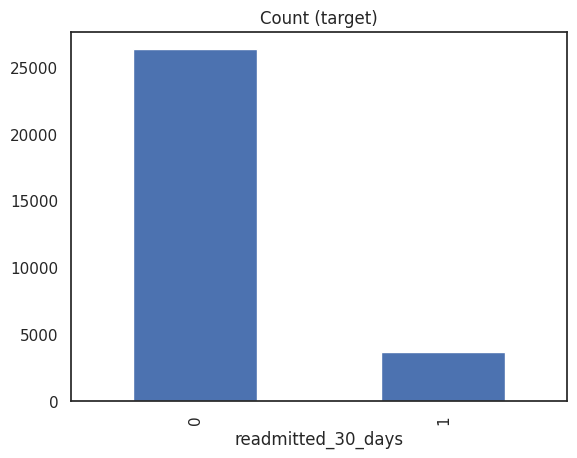

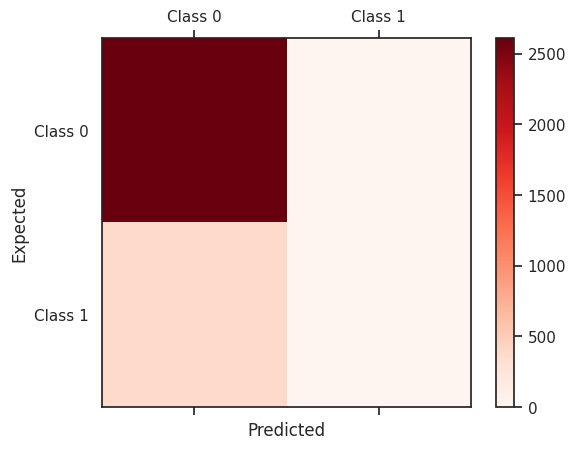

In [431]:
# Confusion Matrix and Class imbalance checking
from sklearn.metrics import confusion_matrix
cfm = confusion_matrix(y_test, y_pred)
print(cfm)
labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cfm, cmap=plt.cm.Reds)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

## Class Imbalance

In [432]:
# Class Imbalance Processing: Using re-sampling method
from imblearn.over_sampling import SMOTE
from collections import Counter

# Remove non-numeric columns before SMOTE
train_input_numeric = train_input.select_dtypes(include=['int64', 'float64'])

print('Original dataset shape {}'.format(Counter(train_output)))
sm = SMOTE(random_state=20)
train_input_new, train_output_new = sm.fit_resample(train_input_numeric, train_output)
print('New dataset shape {}'.format(Counter(train_output_new)))

Original dataset shape Counter({0: 26326, 1: 3674})
New dataset shape Counter({1: 26326, 0: 26326})


## LOgistic Regressor

In [433]:
# define Logistic Regression model
log_reg = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)

# fit on resampled training data
log_reg.fit(X_train_sm, y_train_sm)

# adjust threshold
y_proba = log_reg.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.15).astype(int)

# evaluate
print("Test Set score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Test Set score: 0.6036666666666667
[[1611 1004]
 [ 185  200]]
              precision    recall  f1-score   support

           0       0.90      0.62      0.73      2615
           1       0.17      0.52      0.25       385

    accuracy                           0.60      3000
   macro avg       0.53      0.57      0.49      3000
weighted avg       0.80      0.60      0.67      3000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


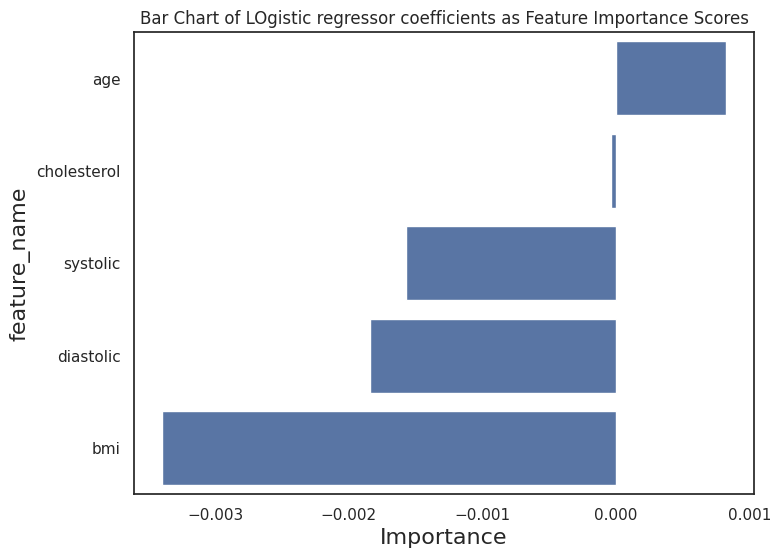

In [434]:
# get importance
importance = log_reg.coef_[0]

imp_df = pd.DataFrame({'feature_name':X_features, 'Importance':importance})
fi = imp_df.sort_values(by='Importance', ascending=False).head()

# plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(data=fi, x= 'Importance', y='feature_name')
plt.xlabel('Importance', fontsize=16)
plt.ylabel('feature_name', fontsize=16)
plt.title('Bar Chart of LOgistic regressor coefficients as Feature Importance Scores')
plt.show()

#XGBClassifier

In [435]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# define XGBoost model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'

)

# fit on resampled training data
xgb.fit(X_train_sm, y_train_sm)

# adjust threshold
y_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.15).astype(int)

# evaluate
print("Test Set score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Test Set score: 0.635
[[1745  870]
 [ 225  160]]
              precision    recall  f1-score   support

           0       0.89      0.67      0.76      2615
           1       0.16      0.42      0.23       385

    accuracy                           0.64      3000
   macro avg       0.52      0.54      0.49      3000
weighted avg       0.79      0.64      0.69      3000



In [436]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC      :", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy : 0.8703333333333333
AUC      : 0.5527396886096695
Precision: 0.0
Recall   : 0.0


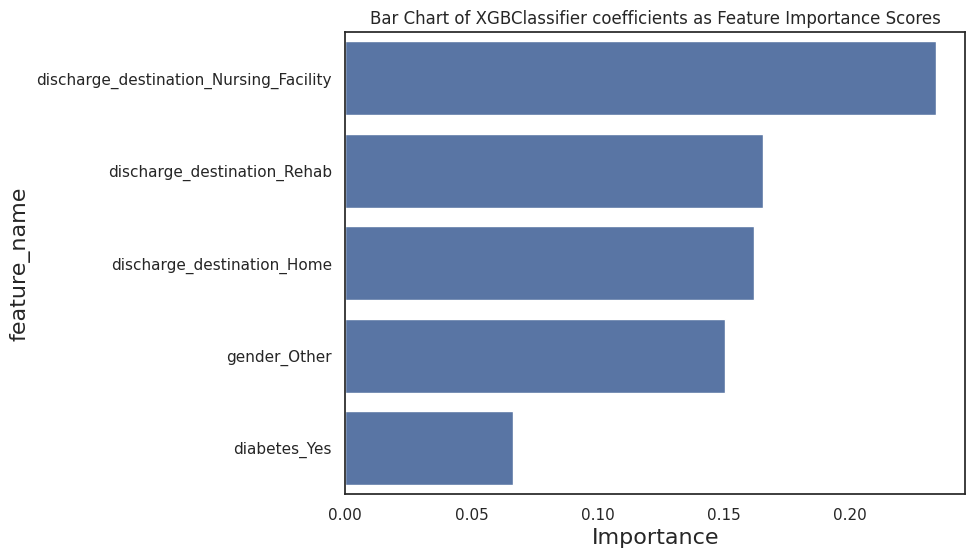

In [437]:
# get importance
importance = xgb.feature_importances_


imp_df = pd.DataFrame({'feature_name':X_features, 'Importance':importance})
fi = imp_df.sort_values(by='Importance', ascending=False).head()

# plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(data=fi, x= 'Importance', y='feature_name')
plt.xlabel('Importance', fontsize=16)
plt.ylabel('feature_name', fontsize=16)
plt.title('Bar Chart of XGBClassifier coefficients as Feature Importance Scores')
plt.show()

[[2611    4]
 [ 385    0]]


/tmp/ipykernel_4695/1859710546.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
/tmp/ipykernel_4695/1859710546.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


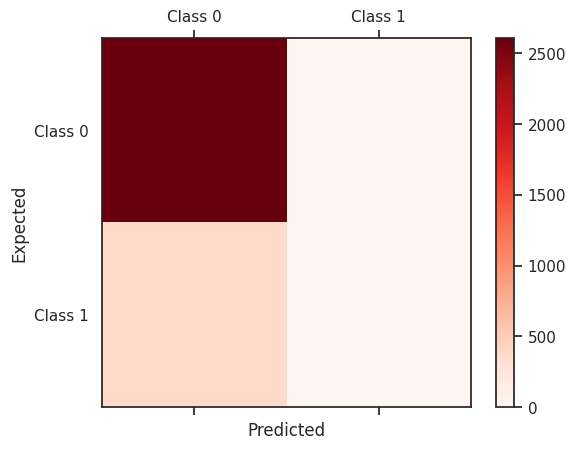

In [438]:
# Confusion Matrix and Class imbalance cehcking
from sklearn.metrics import confusion_matrix
cfm = confusion_matrix(y_test, y_pred)
print(cfm)
labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cfm, cmap=plt.cm.Reds)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

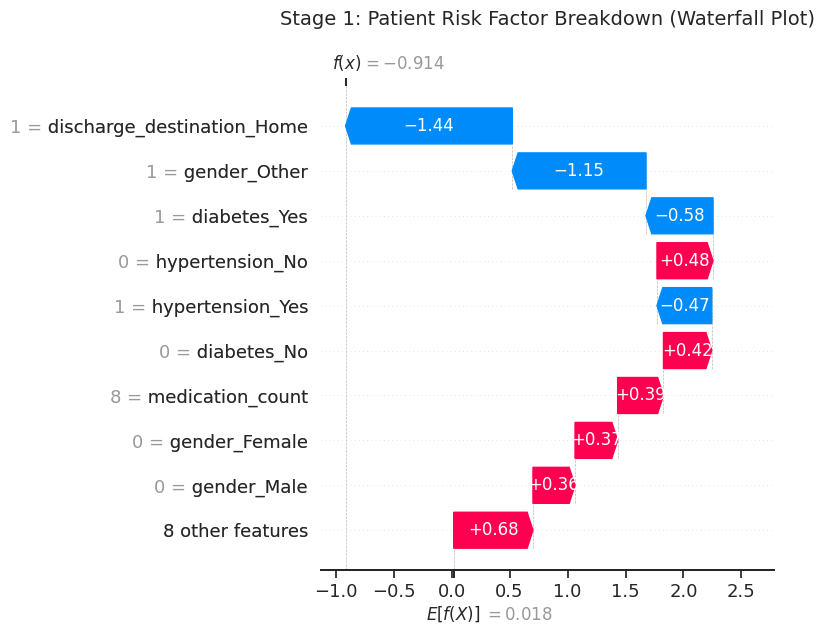

👉 Look at the bars: Red bars push the patient TOWARD readmission (+). Blue bars pull them AWAY (-).


In [439]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer using your existing XGBoost model
explainer = shap.TreeExplainer(xgb)

# 2. Calculate SHAP values (Keep the full object structure for the waterfall plot)
shap_values_object = explainer(X_test)

# 3. Generate the Waterfall Plot for the FIRST patient in your test set (index 0)
plt.figure(figsize=(10, 6))
# Using index 0 looks at patient #1. You can change this to 1, 2, or 3 to see other patients.
shap.plots.waterfall(shap_values_object[0], max_display=10, show=False)

plt.title("Stage 1: Patient Risk Factor Breakdown (Waterfall Plot)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("👉 Look at the bars: Red bars push the patient TOWARD readmission (+). Blue bars pull them AWAY (-).")

## XGBoost Hyperparameter Tuning (GridSearchCV)

---



In [440]:


param_grid = {
    'max_depth': [3, 7, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'scale_pos_weight': [7]
}

# 2. Initialize a fresh XGBoost instance
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Setup Grid Search optimizing for
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print("Starting Hyperparameter Tuning...")

grid_search.fit(X_train, y_train)


best_xgb_model = grid_search.best_estimator_


y_pred_tuned = best_xgb_model.predict(X_test)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)

print("\n=== Tuned Model Performance ===")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))


Starting Hyperparameter Tuning...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== Best Parameters Found ===
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 7}

=== Tuned Model Performance ===
[[1885  730]
 [ 219  166]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      2615
           1       0.19      0.43      0.26       385

    accuracy                           0.68      3000
   macro avg       0.54      0.58      0.53      3000
weighted avg       0.80      0.68      0.73      3000



In [441]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# define XGBoost model with TUNED parameters
xgb_best = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.2,
    scale_pos_weight=7,
    random_state=42,
    eval_metric='logloss'
)

# fit on resampled training data
xgb_best.fit(X_train_sm, y_train_sm)

# adjust threshold
y_proba = xgb_best.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.6).astype(int)

# evaluate
print("Test Set score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Test Set score: 0.7256666666666667
[[2055  560]
 [ 263  122]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      2615
           1       0.18      0.32      0.23       385

    accuracy                           0.73      3000
   macro avg       0.53      0.55      0.53      3000
weighted avg       0.80      0.73      0.76      3000



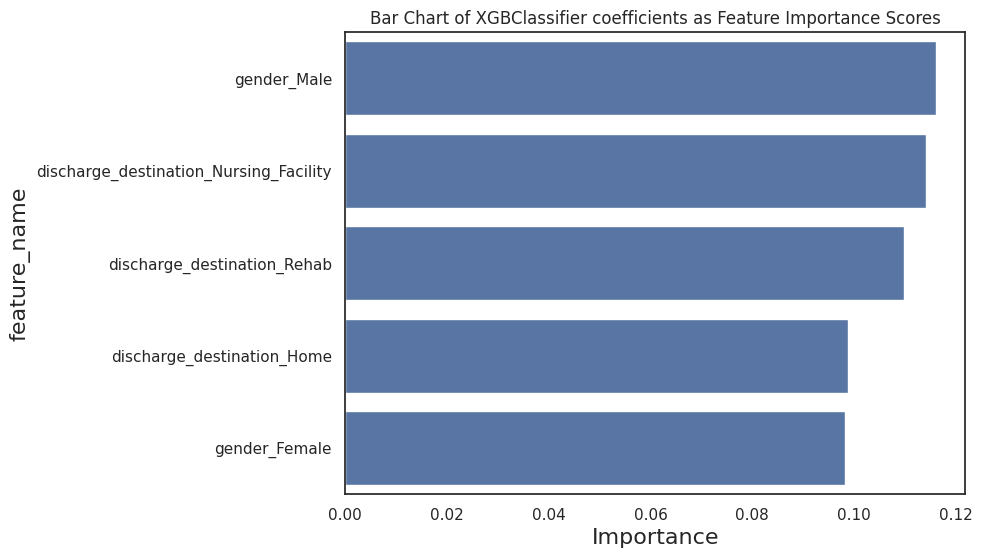

In [442]:
# get importance
importance = xgb_best.feature_importances_

imp_df = pd.DataFrame({'feature_name':X_features, 'Importance':importance})
fi = imp_df.sort_values(by='Importance', ascending=False).head()

# plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(data=fi, x= 'Importance', y='feature_name')
plt.xlabel('Importance', fontsize=16)
plt.ylabel('feature_name', fontsize=16)
plt.title('Bar Chart of XGBClassifier coefficients as Feature Importance Scores')
plt.show()